# **1DCNN модель, для задачм предсказания ECM параметров**.

## Загрузка данных

Библиотеки

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import copy

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from tqdm import tqdm
import os
import random

Распаковка данных

In [2]:
!python -m zipfile -e /content/param_ecm-new_data_param.zip /content/

### Загрузка датасетов.

In [3]:
target_path = r'/content/param_ecm-new_data_param/plsDS_soc455055_fr2_1RC_R0free_main.csv'

feature_path = r'/content/param_ecm-new_data_param/plsDS_soc455055_fr2_1RC_R0free_pls_tables'

## Обработка Датасетов

#### Обработка X (features)

In [58]:
X_data_dict = {}

for filename in os.listdir(feature_path):
  if filename.endswith('.csv'):
    full_path = os.path.join(feature_path, filename)

    X_data_dict[filename] = pd.read_csv(full_path)[['Time', 'I', 'E']]

filenames_list = list(X_data_dict.keys())

print(f"Всего файлов загружено: {len(filenames_list)}")
print(f"Первый файл: {filenames_list[0]}")

Всего файлов загружено: 72
Первый файл: soc55_05Cdch_36sec.csv


#### Обработка y (target)

In [59]:
y_data = pd.read_csv(target_path)
y_data.head(3)

,I,R0,R1,R2,Udrop,Ufin,Uinit,cellcap,dSoC,dltQ,name,nominal_soc,tau1,tau2,tau_pls,table_file
0,-1.699624,0.035922,0.021680,0.002503,0.0576,3.6642,3.6656,3.36,-0.001265,-15.296620,soc45_05Cdch_9sec,0.45,49.006981,100,9,soc45_05Cdch_9sec.csv
1,-1.699615,0.038267,0.026703,0.004275,0.0596,3.6627,3.6653,3.36,-0.002529,-30.593065,soc45_05Cdch_18sec,0.45,71.978738,100,18,soc45_05Cdch_18sec.csv
2,-1.699670,0.039573,0.029765,0.006881,0.0597,3.6611,3.6656,3.36,-0.005059,-61.188125,soc45_05Cdch_36sec,0.45,98.442333,100,36,soc45_05Cdch_36sec.csv


In [60]:
first_filename = filenames_list[0]
first_dataframe = X_data_dict[first_filename]

first_dataframe.head(3)

,Time,I,E
0,0.0,-1.6982,3.6996
1,0.1,-1.6982,3.6996
2,0.2,-1.6984,3.6988


### Преобразуем данные, оставим, только R0, R1, R2, tau1, tau2, table_file, tau_pls.

In [61]:
y_data_valid = y_data.copy()

y_data_valid = y_data_valid[['R0', 'R1', 'R2', 'tau1', 'tau2', 'table_file', 'tau_pls', 'Ufin']]
y_data_valid.head(3)

,R0,R1,R2,tau1,tau2,table_file,tau_pls,Ufin
0,0.035922,0.021680,0.002503,49.006981,100,soc45_05Cdch_9sec.csv,9,3.6642
1,0.038267,0.026703,0.004275,71.978738,100,soc45_05Cdch_18sec.csv,18,3.6627
2,0.039573,0.029765,0.006881,98.442333,100,soc45_05Cdch_36sec.csv,36,3.6611


In [62]:
y_data_valid = y_data_valid.set_index('table_file')
y_data_valid.head(3)

,R0,R1,R2,tau1,tau2,tau_pls,Ufin
table_file,,,,,,,
soc45_05Cdch_9sec.csv,0.035922,0.021680,0.002503,49.006981,100,9,3.6642
soc45_05Cdch_18sec.csv,0.038267,0.026703,0.004275,71.978738,100,18,3.6627
soc45_05Cdch_36sec.csv,0.039573,0.029765,0.006881,98.442333,100,36,3.6611


#### Проверю доступность строк.

In [63]:
y_data_valid.loc['soc45_05Cdch_9sec.csv']

,soc45_05Cdch_9sec.csv
R0,0.035922
R1,0.021680
R2,0.002503
tau1,49.006981
tau2,100.000000
tau_pls,9.000000
Ufin,3.664200


#### Преобразуем tau в C по формуле C = tau / R

In [64]:
y_data_ECM = y_data_valid.copy()
y_data_ECM['C1'] = y_data_ECM['tau1'] / y_data_ECM['R1']
y_data_ECM['C2'] = y_data_ECM['tau2'] / y_data_ECM['R2']
y_data_ECM = y_data_ECM.drop(columns = ['tau1', 'tau2'])
y_data_ECM

,R0,R1,R2,tau_pls,Ufin,C1,C2
table_file,,,,,,,
soc45_05Cdch_9sec.csv,0.035922,0.021680,0.002503,9,3.6642,2260.448803,39953.664553
soc45_05Cdch_18sec.csv,0.038267,0.026703,0.004275,18,3.6627,2695.552979,23393.126693
soc45_05Cdch_36sec.csv,0.039573,0.029765,0.006881,36,3.6611,3307.338185,14533.132864
soc45_05Cdch_72sec.csv,0.040419,0.026845,0.009549,72,3.6576,4039.711416,10472.793336
soc45_05Cdch_144sec.csv,0.041387,0.024470,0.012494,144,3.6510,5041.127631,8003.795124
...,...,...,...,...,...,...,...
soc55_1Cchr_36sec.csv,0.037162,0.015144,0.004966,36,3.7599,2894.353334,20136.191961
soc55_1Cchr_72sec.csv,0.037716,0.014151,0.006390,72,3.7600,3256.514024,15650.545530
soc55_2Cchr_9sec.csv,0.035879,0.016251,0.002251,9,3.7600,2243.239787,44432.795075


In [65]:
common_keys = sorted(set(X_data_dict.keys()) & set(y_data_ECM.index))

X_df = {
    key: [
        float(y_data_ECM.loc[key, 'tau_pls']),
        X_data_dict[key].iloc[:3000][['Time', 'I', 'E']].copy()
    ]
    for key in common_keys
}

print(f"Общих ключей между X и y: {len(common_keys)}")
X_df['soc45_05Cdch_9sec.csv']

Общих ключей между X и y: 72


[9.0,
        Time       I       E
 0       0.0 -1.6987  3.6080
 1       0.1 -1.6987  3.6080
 2       0.2 -1.6988  3.6077
 3       0.3 -1.6991  3.6074
 4       0.4 -1.6992  3.6068
 ...     ...     ...     ...
 2995  299.4  0.0000  3.6640
 2996  299.5  0.0000  3.6640
 2997  299.6  0.0000  3.6640
 2998  299.7  0.0000  3.6640
 2999  299.8  0.0000  3.6640
 
 [3000 rows x 3 columns]]

In [66]:
y_data_ECM.loc['soc45_05Cdch_9sec.csv']

,soc45_05Cdch_9sec.csv
R0,0.035922
R1,0.021680
R2,0.002503
tau_pls,9.000000
Ufin,3.664200
C1,2260.448803
C2,39953.664553


## Разобьем данные на train и validation

In [67]:
csv_names = sorted(X_df.keys())

tau_for_split = pd.Series(
    {key: X_df[key][0] for key in csv_names},
    name='tau_pls'
)

tau_counts = tau_for_split.value_counts()
can_stratify = tau_counts.min() >= 2

In [68]:
train_keys, val_keys = train_test_split(
    csv_names,
    test_size=0.2,
    random_state=42,
    stratify=tau_for_split.loc[csv_names] if can_stratify else None
)

train_keys = sorted(train_keys)
val_keys = sorted(val_keys)

In [71]:
X_train_data = {key: X_df[key] for key in train_keys}
X_val_data = {key: X_df[key] for key in val_keys}

In [72]:
print(f"Всего профилей: {len(csv_names)}")
print(f"Train: {len(X_train_data)}")
print(f"Val: {len(X_val_data)}")
print("\nРаспределение tau_pls в train:")
print(pd.Series({k: X_train_data[k][0] for k in train_keys}).value_counts().sort_index())
print("\nРаспределение tau_pls в val:")
print(pd.Series({k: X_val_data[k][0] for k in val_keys}).value_counts().sort_index())

Всего профилей: 72
Train: 57
Val: 15

Распределение tau_pls в train:
9.0      19
18.0     14
36.0      9
72.0     10
144.0     5
Name: count, dtype: int64

Распределение tau_pls в val:
9.0      5
18.0     4
36.0     3
72.0     2
144.0    1
Name: count, dtype: int64


In [73]:
print(train_keys)

['soc45_05Cchr_144sec.csv', 'soc45_05Cchr_36sec.csv', 'soc45_05Cchr_72sec.csv', 'soc45_05Cchr_9sec.csv', 'soc45_05Cdch_144sec.csv', 'soc45_05Cdch_18sec.csv', 'soc45_05Cdch_9sec.csv', 'soc45_1Cchr_18sec.csv', 'soc45_1Cchr_36sec.csv', 'soc45_1Cchr_72sec.csv', 'soc45_1Cchr_9sec.csv', 'soc45_1Cdch_18sec.csv', 'soc45_1Cdch_36sec.csv', 'soc45_1Cdch_72sec.csv', 'soc45_1Cdch_9sec.csv', 'soc45_2Cchr_18sec.csv', 'soc45_2Cchr_9sec.csv', 'soc45_2Cdch_18sec.csv', 'soc45_2Cdch_9sec.csv', 'soc50_05Cchr_144sec.csv', 'soc50_05Cchr_18sec.csv', 'soc50_05Cchr_36sec.csv', 'soc50_05Cchr_9sec.csv', 'soc50_05Cdch_18sec.csv', 'soc50_05Cdch_36sec.csv', 'soc50_05Cdch_72sec.csv', 'soc50_05Cdch_9sec.csv', 'soc50_1Cchr_72sec.csv', 'soc50_1Cdch_18sec.csv', 'soc50_1Cdch_36sec.csv', 'soc50_1Cdch_72sec.csv', 'soc50_1Cdch_9sec.csv', 'soc50_2Cchr_18sec.csv', 'soc50_2Cchr_9sec.csv', 'soc50_2Cdch_9sec.csv', 'soc50_3Cdch_9sec.csv', 'soc55_05Cchr_144sec.csv', 'soc55_05Cchr_18sec.csv', 'soc55_05Cchr_72sec.csv', 'soc55_05Cchr_

In [77]:
y_train_full = y_data_ECM.loc[train_keys].copy()
y_val_full = y_data_ECM.loc[val_keys].copy()

target_cols = ['R0', 'R1', 'R2', 'C1', 'C2']

y_train = y_train_full[target_cols].copy()
y_val = y_val_full[target_cols].copy()

print("y_train_full:", y_train_full.shape)
print("y_val_full:", y_val_full.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

y_train_full: (57, 7)
y_val_full: (15, 7)
y_train: (57, 5)
y_val: (15, 5)


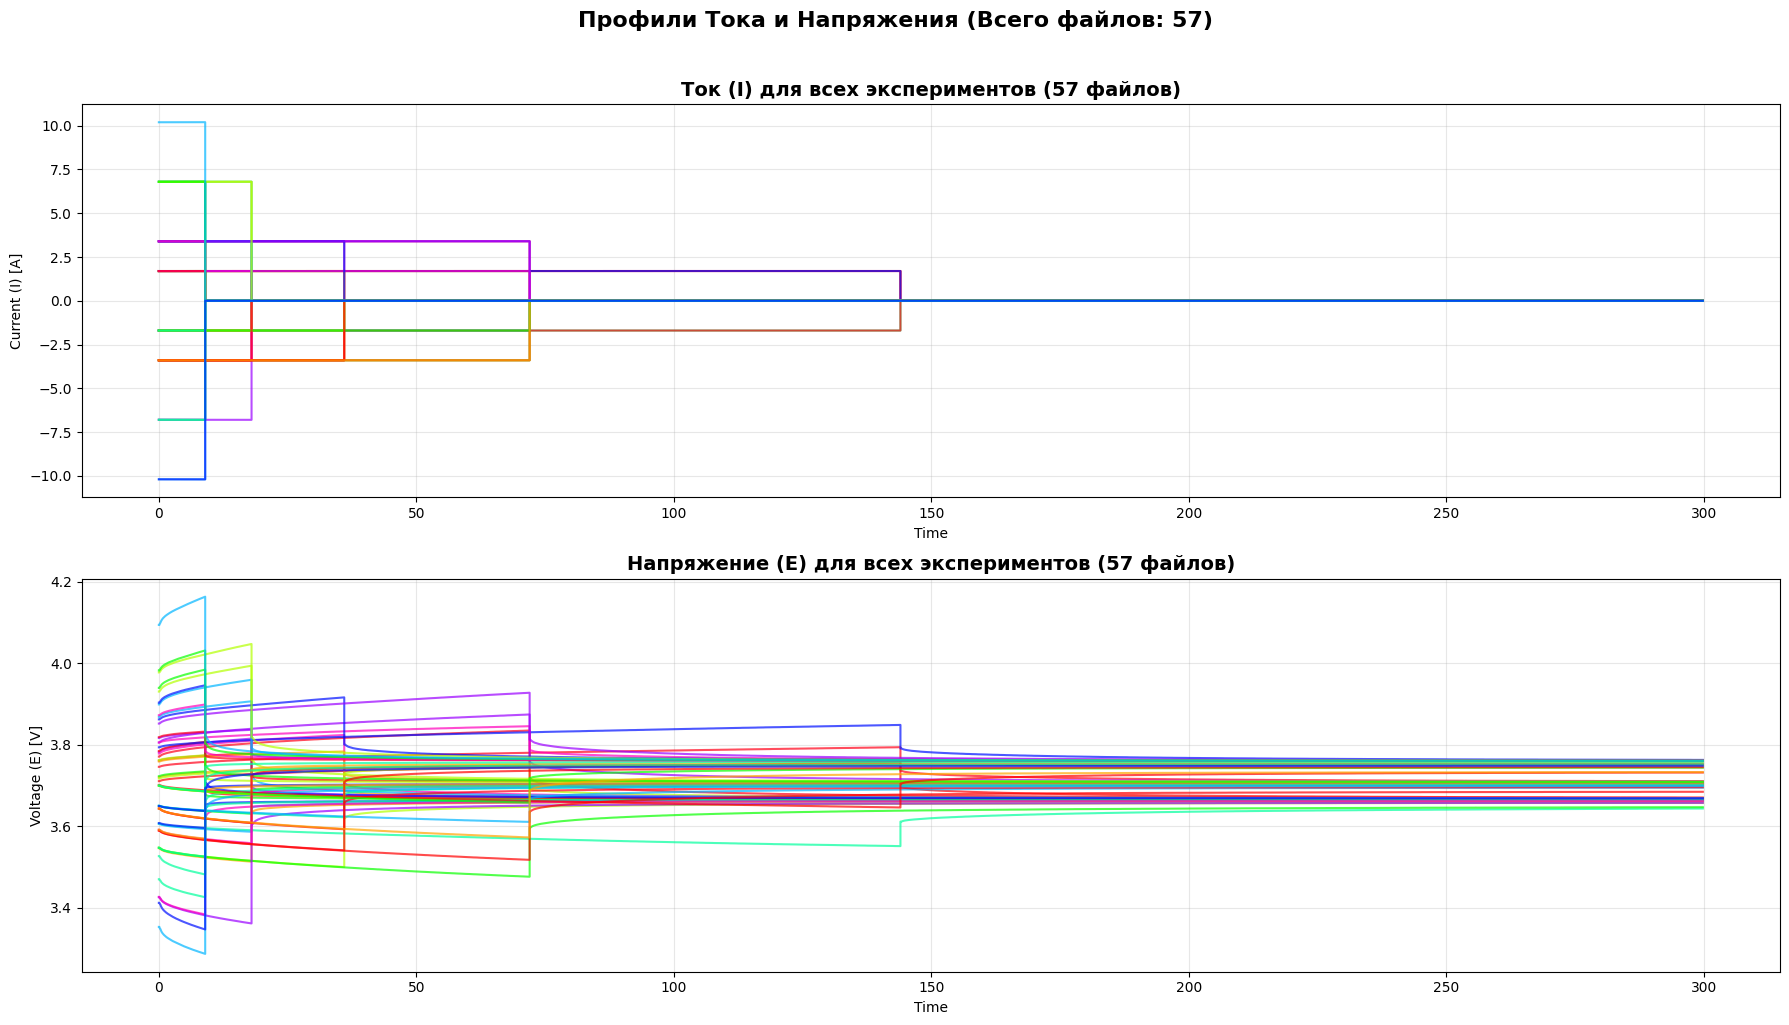

In [78]:
filenames_list = sorted([f for f in X_train_data.keys() if f.endswith('.csv')])
files_to_plot = filenames_list

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 10))
ax_I = axes[0]
ax_E = axes[1]

colors = plt.cm.hsv(np.linspace(0, 1, 10))

for i, filename in enumerate(files_to_plot):
    if len(X_train_data[filename]) < 2:
        continue

    df = X_train_data[filename][1]

    if 'Time' not in df.columns or 'I' not in df.columns or 'E' not in df.columns:
        continue

    df_plot = df
    color = colors[i % len(colors)]

    ax_I.plot(df_plot['Time'], df_plot['I'],
              color=color, linewidth=1.5, alpha=0.7,
              label=f'{filename}')

    ax_E.plot(df_plot['Time'], df_plot['E'],
              color=color, linewidth=1.5, alpha=0.7,
              label=f'{filename}', linestyle='-')

ax_I.set_title(f'Ток (I) для всех экспериментов ({len(files_to_plot)} файлов)', fontsize=14, fontweight='bold')
ax_I.set_xlabel('Time')
ax_I.set_ylabel('Current (I) [A]')
ax_I.grid(True, alpha=0.3)

ax_E.set_title(f'Напряжение (E) для всех экспериментов ({len(files_to_plot)} файлов)', fontsize=14, fontweight='bold')
ax_E.set_xlabel('Time')
ax_E.set_ylabel('Voltage (E) [V]')
ax_E.grid(True, alpha=0.3)

if len(files_to_plot) <= 15:
    ax_I.legend(loc='upper right', fontsize=8)
    ax_E.legend(loc='upper right', fontsize=8)

plt.suptitle(f'Профили Тока и Напряжения (Всего файлов: {len(files_to_plot)})', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Данные и их статистики.

#### Features

In [79]:
X_train_statistics = []
X_train_time_pls = []

for i, key in enumerate(train_keys):
  X_train_statistics.append(X_train_data[key][1].values)
  X_train_time_pls.append(X_train_data[key][0])

In [80]:
stats_list = []

for i, data_item in enumerate(X_train_statistics):

    arr = np.array(data_item)


    # Извлекаем колонки по индексам: 0 - Время, 1 - Ток, 2 - Напряжение
    time_series = arr[:, 0]
    current_series = arr[:, 1]
    voltage_series = arr[:, 2]
    actual_length = len(time_series)

    def get_stats(series):
        return {
            'min': np.min(series),
            'max': np.max(series),
            'mean': np.mean(series),
            'std': np.std(series),
        }

    stats_v = get_stats(voltage_series)
    stats_c = get_stats(current_series)

    stats = {
        'key': train_keys[i],
        'tau_pls': X_train_time_pls[i],
        'length': actual_length,

        # Напряжение (Voltage)
        'volt_min': stats_v['min'],
        'volt_max': stats_v['max'],
        'volt_mean': stats_v['mean'],
        'volt_std': stats_v['std'],

        # Ток (Current)
        'curr_min': stats_c['min'],
        'curr_max': stats_c['max'],
        'curr_mean': stats_c['mean'],
        'curr_std': stats_c['std'],
    }

    stats_list.append(stats)

df_stats = pd.DataFrame(stats_list)

print("Статистика по тренировочным последовательностям:")
df_stats

Статистика по тренировочным последовательностям:


,key,tau_pls,length,volt_min,volt_max,volt_mean,volt_std,curr_min,curr_max,curr_mean,curr_std
0,soc45_05Cchr_144sec.csv,144.0,3000,3.6705,3.7563,3.707622,0.034423,0.0000,1.6999,0.816483,0.849255
1,soc45_05Cchr_36sec.csv,36.0,3000,3.6671,3.7461,3.677795,0.022348,0.0000,1.6999,0.204547,0.553043
2,soc45_05Cchr_72sec.csv,72.0,3000,3.6683,3.7516,3.688406,0.029990,0.0000,1.6999,0.408525,0.726313
3,soc45_05Cchr_9sec.csv,9.0,3000,3.6657,3.7349,3.668629,0.011038,0.0000,1.6999,0.051556,0.291496
4,soc45_05Cdch_144sec.csv,144.0,3000,3.5513,3.6436,3.605028,0.034159,-1.6998,0.0000,-0.816435,0.849205
5,soc45_05Cdch_18sec.csv,18.0,3000,3.5866,3.6618,3.656005,0.015995,-1.6997,0.0000,-0.102543,0.404682
6,soc45_05Cdch_9sec.csv,9.0,3000,3.5961,3.6640,3.661099,0.010789,-1.6997,0.0000,-0.051555,0.291490
7,soc45_1Cchr_18sec.csv,18.0,3000,3.6683,3.8153,3.678866,0.031961,0.0000,3.3998,0.205116,0.809483
8,soc45_1Cchr_36sec.csv,36.0,3000,3.6689,3.8243,3.689251,0.044677,0.0000,3.3998,0.409105,1.106116
9,soc45_1Cchr_72sec.csv,72.0,3000,3.6697,3.8351,3.709251,0.059919,0.0000,3.3999,0.817079,1.452675


##### Группируем по tau_pls

In [84]:
def create_grouped_statistics_multi(df_stats: pd.DataFrame, group_by: str = 'tau_pls') -> pd.DataFrame:
    aggregations = {
        'length': ['count', 'mean', 'min', 'max'],
        'volt_min': ['mean', 'std', 'min', 'max'],
        'volt_max': ['mean', 'std', 'min', 'max'],
        'volt_mean': ['mean', 'std', 'min', 'max'],
        'volt_std': ['mean', 'std', 'min', 'max'],
        'curr_min': ['mean', 'std', 'min', 'max'],
        'curr_max': ['mean', 'std', 'min', 'max'],
        'curr_mean': ['mean', 'std', 'min', 'max'],
        'curr_std': ['mean', 'std', 'min', 'max'],
    }

    grouped = df_stats.groupby(group_by).agg(aggregations)
    grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]

    if 'length_count' in grouped.columns:
        grouped['length_count'] = grouped['length_count'].astype(int)

    return grouped.sort_index()

grouped_stats = create_grouped_statistics_multi(df_stats, 'tau_pls')
grouped_stats.T

tau_pls,9.0,18.0,36.0,72.0,144.0
length_count,19.000000,14.000000,9.000000,10.000000,5.000000
length_mean,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
length_min,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
length_max,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
volt_min_mean,3.600053,3.641021,3.636711,3.640670,3.668340
volt_min_std,0.150723,0.111132,0.081791,0.096405,0.078995
volt_min_min,3.286800,3.361500,3.500200,3.476200,3.551300
volt_min_max,3.760900,3.760900,3.761000,3.761800,3.763000
volt_max_mean,3.801879,3.802400,3.757822,3.773850,3.755000
volt_max_std,0.140919,0.129973,0.077351,0.091955,0.076313


#### Целевые переменные.

In [102]:
y_train_full.groupby('tau_pls')[['R0', 'R1', 'R2', 'C1', 'C2', 'Ufin']].agg(['count', 'min', 'max', 'mean', 'std']).T

tau_pls              9             18            36            72   \
R0   count     19.000000     14.000000      9.000000     10.000000   
     min        0.035610      0.036193      0.036905      0.037716   
     max        0.038178      0.039004      0.040249      0.041219   
     mean       0.036698      0.037502      0.038110      0.038988   
     std        0.000805      0.000955      0.001032      0.001088   
R1   count     19.000000     14.000000      9.000000     10.000000   
     min        0.011923      0.012850      0.013272      0.012715   
     max        0.026545      0.026703      0.022186      0.020172   
     mean       0.016874      0.016897      0.016412      0.015710   
     std        0.004753      0.004298      0.003500      0.002468   
R2   count     19.000000     14.000000      9.000000     10.000000   
     min        0.001788      0.002835      0.004178      0.005443   
     max        0.002830      0.004275      0.005936      0.007867   
     mean       0.002165      0.003380      0.004853      0.006625   
     std        0.000321      0.000475      0.000700      0.000733   
C1   count     19.000000     14.000000      9.000000     10.000000   
     min     2072.970226   2386.352262   2894.353334   3243.412199   
     max     2451.714727   2846.628699   3282.074009   4270.768826   
     mean    2288.728510   2625.599314   3112.750595   3683.080066   
     std      105.252606    131.708082    124.499075    340.135357   
C2   count     19.000000     14.000000      9.000000     10.000000   
     min    35331.897611  23393.126693  16846.672983  12710.680341   
     max    55921.525371  35278.532731  23937.021680  18371.589164   
     mean   47113.827820  30090.217419  20965.537405  15259.736508   
     std     6690.655420   3898.316326   2810.897635   1683.785502   
Ufin count     19.000000     14.000000      9.000000     10.000000   
     min        3.662600      3.658700      3.658500      3.650900   
     max        3.760500      3.760200      3.759900      3.760200   
     mean       3.711653      3.709300      3.706344      3.707910   
     std        0.039429      0.041415      0.038880      0.040552   

tau_pls              144  
R0   count      5.000000  
     min        0.038570  
     max        0.041387  
     mean       0.039975  
     std        0.001264  
R1   count      5.000000  
     min        0.012897  
     max        0.024470  
     mean       0.016106  
     std        0.004731  
R2   count      5.000000  
     min        0.007097  
     max        0.012494  
     mean       0.008732  
     std        0.002141  
C1   count      5.000000  
     min     3954.524758  
     max     5051.794002  
     mean    4558.986903  
     std      507.137869  
C2   count      5.000000  
     min     8003.795124  
     max    14089.717035  
     mean   11897.230305  
     std     2289.065019  
Ufin count      5.000000  
     min        3.651000  
     max        3.760600  
     mean       3.704660  
     std        0.045760

### Генерируем синтетические данные.

##### Параметры модели ECM (2RC) для литий-ионной ячейки

**Таблица параметров цепи:**

| Параметр | Обозначение | Значение | Ед. изм. | Описание |
| :--- | :---: | :---: | :---: | :--- |
| Омическое сопротивление | $R_0$ | **0.05** | Ом | Мгновенное падение напряжения |
| Сопротивление поляризации 1 | $R_1$ | **0.03** | Ом | Быстрая переходная характеристика |
| Емкость поляризации 1 | $C_1$ | **1500** | Ф | Быстрая переходная характеристика |
| Сопротивление поляризации 2 | $R_2$ | **0.02** | Ом | Медленная переходная характеристика |
| Емкость поляризации 2 | $C_2$ | **15000** | Ф | Медленная переходная характеристика |
| Напряжение холостого хода | $OCV_{ref}$ | **3.7** | В | Опорное напряжение |
| Шаг дискретизации | $\Delta t$ | **0.1** | с | Временной шаг моделирования |

**Профиль токовой нагрузки:**

Моделирование проводится на временном интервале $t \in [0, 600]$ с шагом $\Delta t = 0.1$. Профиль тока $I(t)$ задан следующим образом:

$$
I(t) =
\begin{cases}
2.0 \, \text{A}, & \text{если } 5 \le t < 15 \, \text{с} \\
1.5 \, \text{A}, & \text{если } 30 \le t < 50 \, \text{с} \\
0 \, \text{A}, & \text{в остальных случаях}
\end{cases}
$$

> *Примечание: Индексы массива в коде (50:150 и 300:500) соответствуют указанным временным интервалам при шаге дискретизации 0.1 с.*

In [53]:
def simulate_ecm(current, dt, R0, R1, C1, R2, C2, OCV):
    v1, v2 = 0, 0
    v_terminal = np.zeros_like(current)
    phi1 = np.exp(-dt / (R1 * C1))
    phi2 = np.exp(-dt / (R2 * C2))
    for i in range(len(current)):
        v1 = phi1 * v1 + R1 * (1 - phi1) * current[i]
        v2 = phi2 * v2 + R2 * (1 - phi2) * current[i]
        v_terminal[i] = OCV - current[i] * R0 - v1 - v2
    return v_terminal

Функция генерации параметров, учитываю:

1) Cохранение совместных зависимостей между параметрами;

2) Генерация становится физически реалистичнее;

3) Меньше шанс получить “невозможные” комбинации;

4) Есть защита на случай маленьких групп;

5) Не портится глобальный random state.

In [87]:
def generate_ecm_params_from_y_train(y_train_df, n_samples=1, tau_pls=9.0, seed=None):
    param_cols = ['R0', 'R1', 'R2', 'C1', 'C2', 'Ufin']

    group = y_train_df.loc[y_train_df['tau_pls'] == tau_pls, param_cols].dropna().copy()

    rng = np.random.default_rng(seed)

    if len(group) == 1:
        samples = np.repeat(group.to_numpy(dtype=float), n_samples, axis=0)
    else:
        mu = group.mean().to_numpy(dtype=float)
        cov = group.cov().to_numpy(dtype=float)
        cov = np.nan_to_num(cov, nan=0.0)
        cov += np.eye(len(param_cols)) * 1e-12

        try:
            samples = rng.multivariate_normal(mu, cov, size=n_samples)
        except np.linalg.LinAlgError:
            sigma = group.std(ddof=1).fillna(0.0).to_numpy(dtype=float)
            sigma = np.where(sigma > 0, sigma, 1e-12)
            samples = rng.normal(loc=mu, scale=sigma, size=(n_samples, len(param_cols)))

    mins = group.min().to_numpy(dtype=float)
    maxs = group.max().to_numpy(dtype=float)
    samples = np.clip(samples, mins, maxs)

    samples_df = pd.DataFrame(samples, columns=param_cols)

    for col in ['R0', 'R1', 'R2', 'C1', 'C2']:
        samples_df[col] = samples_df[col].clip(lower=1e-12)

    return samples_df.iloc[0].to_dict() if n_samples == 1 else samples_df

In [88]:
single_params = generate_ecm_params_from_y_train(
    y_train_full,
    n_samples=1,
    tau_pls=9.0,
    seed=42
)

print("Сгенерированные параметры (один набор):")
print(f"R0 = {single_params['R0']:.6f}")
print(f"R1 = {single_params['R1']:.6f}")
print(f"R2 = {single_params['R2']:.6f}")
print(f"C1 = {single_params['C1']:.6f}")
print(f"C2 = {single_params['C2']:.6f}")
print(f"OCV = {single_params['Ufin']:.6f}")

Сгенерированные параметры (один набор):
R0 = 0.037882
R1 = 0.013108
R2 = 0.002043
C1 = 2214.844555
C2 = 49153.374925
OCV = 3.754554


#### Создаем сетку параметров.

##### Вспомогательные функции

In [91]:
def downsample_profile(df, target_len=300):
    df = df.reset_index(drop=True).copy()

    if len(df) <= target_len:
        return df

    idx = np.linspace(0, len(df) - 1, target_len).round().astype(int)
    idx = np.clip(idx, 0, len(df) - 1)
    idx = np.unique(idx)

    if len(idx) < target_len:
        idx = np.linspace(0, len(df) - 1, target_len).astype(int)

    return df.iloc[idx].reset_index(drop=True)

In [92]:
def convert_real_split_to_dataset(X_split_data, target_len=300):
    data_dict = {}

    for key, (tau_pls, df) in X_split_data.items():
        df_cur = df[['Time', 'I', 'E']].copy()
        data_dict[key] = downsample_profile(df_cur, target_len=target_len)

    return data_dict

In [93]:
def build_augmented_train_dataset(
    X_train_data,
    y_train_full,
    y_train_targets,
    n_synth_per_real=5,
    target_len=300,
    base_seed=42
):
    rng = np.random.default_rng(base_seed)

    train_data = {}
    target_rows = []

    # 1. Добавляем train-профили
    for key, (tau_pls, df_real) in X_train_data.items():
        df_real_small = downsample_profile(df_real[['Time', 'I', 'E']].copy(), target_len=target_len)
        train_data[key] = df_real_small

        row = y_train_targets.loc[key].to_dict()
        row['key'] = key
        target_rows.append(row)

    # 2. Генерируем синтетику на основе реального тока и синтетических ECM-параметров
    for key, (tau_pls, df_real) in X_train_data.items():
        current = df_real['I'].to_numpy(dtype=float)
        time = df_real['Time'].to_numpy(dtype=float)

        if len(time) > 1:
            dt_local = float(np.median(np.diff(time)))
            if not np.isfinite(dt_local) or dt_local <= 0:
                dt_local = 0.1
        else:
            dt_local = 0.1

        batch_params = generate_ecm_params_from_y_train(
            y_train_full,
            n_samples=n_synth_per_real,
            tau_pls=tau_pls,
            seed=int(rng.integers(0, 1_000_000_000))
        )

        for j, (_, params) in enumerate(batch_params.iterrows()):
            voltage = simulate_ecm(
                current=current,
                dt=dt_local,
                R0=float(params['R0']),
                R1=float(params['R1']),
                C1=float(params['C1']),
                R2=float(params['R2']),
                C2=float(params['C2']),
                OCV=float(params['Ufin'])
            )

            syn_key = f"{key}__syn_{j}"

            syn_df = pd.DataFrame({
                'Time': time,
                'I': current,
                'E': voltage
            })

            train_data[syn_key] = downsample_profile(syn_df, target_len=target_len)

            target_rows.append({
                'key': syn_key,
                'R0': float(params['R0']),
                'R1': float(params['R1']),
                'R2': float(params['R2']),
                'C1': float(params['C1']),
                'C2': float(params['C2']),
            })

    y_train_aug = pd.DataFrame(target_rows).set_index('key')

    return train_data, y_train_aug


##### Обработка синтетических данных

In [94]:
val_data = convert_real_split_to_dataset(X_val_data, target_len=300)

# Train расширяем: реальные + синтетические
train_data, y_train = build_augmented_train_dataset(
    X_train_data=X_train_data,
    y_train_full=y_train_full,
    y_train_targets=y_train,
    n_synth_per_real=5,
    target_len=300,

    base_seed=42
)

train_keys = list(train_data.keys())
val_keys = list(val_data.keys())

print(f"Train profiles: {len(train_data)}")
print(f"Val profiles: {len(val_data)}")
print(f"Train targets shape: {y_train.shape}")
print(f"Val targets shape: {y_val.shape}")

Train profiles: 342
Val profiles: 15
Train targets shape: (342, 5)
Val targets shape: (15, 5)


##### Пример

In [96]:
example_key = list(X_train_data.keys())[0]

tau_pls, df_example = X_train_data[example_key]

current = df_example['I'].to_numpy(dtype=float)
time = df_example['Time'].to_numpy(dtype=float)

if len(time) > 1:
    dt = float(np.median(np.diff(time)))
else:
    dt = 0.1

print("Используем профиль:", example_key)
print("tau_pls =", tau_pls)
print("Длина профиля =", len(current))

Используем профиль: soc45_05Cchr_144sec.csv
tau_pls = 144.0
Длина профиля = 3000


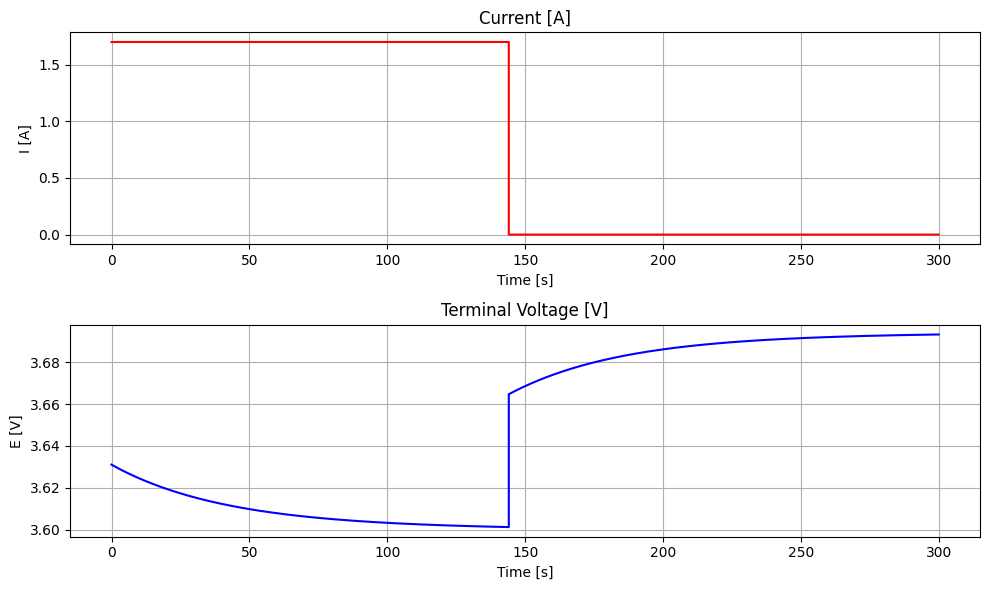

In [97]:
voltage = simulate_ecm(current, dt, R0, R1, C1, R2, C2, OCV)

if 'time' in locals():
    t_plot = np.asarray(time)
else:
    t_plot = np.arange(len(current)) * dt

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t_plot, current, 'r')
plt.title('Current [A]')
plt.xlabel('Time [s]')
plt.ylabel('I [A]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_plot, voltage, 'b')
plt.title('Terminal Voltage [V]')
plt.xlabel('Time [s]')
plt.ylabel('E [V]')
plt.grid(True)

plt.tight_layout()
plt.show()

## Нормировка (Собирание статистик по все train)

In [103]:
feature_cols = ['I', 'E']
target_cols = ['R0', 'R1', 'R2', 'C1', 'C2']

train_keys = [key for key in train_keys if key in train_data and key in y_train.index]
val_keys = [key for key in val_keys if key in val_data and key in y_val.index]

In [104]:
all_train_x = np.concatenate(
    [
        train_data[key][feature_cols].to_numpy(dtype=np.float64)
        for key in train_keys
    ],
    axis=0
)

x_mean = all_train_x.mean(axis=0)
x_std = all_train_x.std(axis=0, ddof=0)

x_std = np.where(x_std < 1e-8, 1.0, x_std)

print("X normalization stats:")
print("feature_cols:", feature_cols)
print("x_mean:", x_mean)
print("x_std :", x_std)

X normalization stats:
feature_cols: ['I', 'E']
x_mean: [0.0101477  3.70591754]
x_std : [1.12281734 0.0603823 ]


In [105]:
all_train_y = y_train.loc[train_keys, target_cols].to_numpy(dtype=np.float64)

y_mean = all_train_y.mean(axis=0)
y_std = all_train_y.std(axis=0, ddof=0)

y_std = np.where(y_std < 1e-8, 1.0, y_std)

print("\nY normalization stats:")
print("target_cols:", target_cols)
print("y_mean:", y_mean)
print("y_std :", y_std)


Y normalization stats:
target_cols: ['R0', 'R1', 'R2', 'C1', 'C2']
y_mean: [3.78101771e-02 1.64905374e-02 4.26435136e-03 2.96485477e+03
 3.06817755e+04]
y_std : [1.42788110e-03 3.36519887e-03 2.35746745e-03 7.39762875e+02
 1.44060025e+04]


In [106]:
x_mean_s = pd.Series(x_mean, index=feature_cols, name='x_mean')
x_std_s  = pd.Series(x_std,  index=feature_cols, name='x_std')

y_mean_s = pd.Series(y_mean, index=target_cols, name='y_mean')
y_std_s  = pd.Series(y_std,  index=target_cols, name='y_std')

display(x_mean_s)
display(x_std_s)
display(y_mean_s)
display(y_std_s)

,x_mean
I,0.010148
E,3.705918


,x_std
I,1.122817
E,0.060382


,y_mean
R0,0.037810
R1,0.016491
R2,0.004264
C1,2964.854775
C2,30681.775537


,y_std
R0,0.001428
R1,0.003365
R2,0.002357
C1,739.762875
C2,14406.002501


## Dataset

In [109]:
class ECMDataset(Dataset):
    def __init__(self, data_dict, target_dict, keys, x_mean, x_std, y_mean, y_std, return_key=False):
        self.return_key = return_key

        # Оставляем только корректные ключи, которые есть и в data_dict, и в target_dict
        self.keys = [key for key in keys if key in data_dict and key in target_dict.index]

        if len(self.keys) == 0:
            raise ValueError("После фильтрации не осталось ни одного корректного key.")

        # Сохраняем статистики нормировки в float32
        self.x_mean = np.asarray(x_mean, dtype=np.float32)
        self.x_std  = np.asarray(x_std, dtype=np.float32)
        self.y_mean = np.asarray(y_mean, dtype=np.float32)
        self.y_std  = np.asarray(y_std, dtype=np.float32)

        # Защита от деления на ноль
        self.x_std = np.where(self.x_std < 1e-8, 1.0, self.x_std)
        self.y_std = np.where(self.y_std < 1e-8, 1.0, self.y_std)

        self.data_arrays = []
        self.target_arrays = []

        expected_len = None

        for key in self.keys:
            df = data_dict[key]

            # Берём только входные признаки
            x = df[['I', 'E']].to_numpy(dtype=np.float32)

            # Проверка одинаковой длины последовательностей
            if expected_len is None:
                expected_len = x.shape[0]
            elif x.shape[0] != expected_len:
                raise ValueError(
                    f"У профиля {key} длина {x.shape[0]}, "
                    f"а ожидалась {expected_len}. "
                    f"Если длины разные, сначала приведи их к одной длине."
                )

            # Нормировка X
            x = (x - self.x_mean) / self.x_std

            # Берём таргет и нормируем его
            y = target_dict.loc[key].to_numpy(dtype=np.float32)
            y = (y - self.y_mean) / self.y_std

            self.data_arrays.append(x)
            self.target_arrays.append(y)

        # Складываем всё в единые массивы
        self.data_arrays = np.stack(self.data_arrays, axis=0).astype(np.float32)   # [N, T, 2]
        self.target_arrays = np.stack(self.target_arrays, axis=0).astype(np.float32)  # [N, 5]

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.data_arrays[idx])
        y = torch.from_numpy(self.target_arrays[idx])

        if self.return_key:
            return x, y, self.keys[idx]

        return x, y

## Подготовка данных: Dataset -> Dataloader

In [110]:
train_dataset = ECMDataset(
    data_dict=train_data,
    target_dict=y_train,
    keys=train_keys,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std,
    return_key=False
)

val_dataset = ECMDataset(
    data_dict=val_data,
    target_dict=y_val,
    keys=val_keys,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std,
    return_key=False
)

print("len(train_dataset) =", len(train_dataset))
print("len(val_dataset)   =", len(val_dataset))

x0, y0 = train_dataset[0]
print("One sample x shape:", x0.shape)   # [T, 2]
print("One sample y shape:", y0.shape)   # [5]

len(train_dataset) = 342
len(val_dataset)   = 15
One sample x shape: torch.Size([300, 2])
One sample y shape: torch.Size([5])


In [113]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [114]:
x_batch, y_batch = next(iter(train_loader))

print("x_batch.shape =", x_batch.shape)   # [B, T, 2]
print("y_batch.shape =", y_batch.shape)   # [B, 5]

x_batch.shape = torch.Size([16, 300, 2])
y_batch.shape = torch.Size([16, 5])


## Модель на основе 1D-CNN

In [116]:
class D1_CNN(nn.Module):
    def __init__(self, input_size=2, out_size=5, hiden_size=32, dropout=0.15):
        super().__init__()

        h = hiden_size

        self.features = nn.Sequential(
            nn.Conv1d(input_size, h, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(h),
            nn.SiLU(),

            nn.Conv1d(h, h * 2, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(h * 2),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Conv1d(h * 2, h * 4, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(h * 4),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Conv1d(h * 4, h * 8, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(h * 8),
            nn.SiLU(),

            nn.Conv1d(h * 8, h * 8, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm1d(h * 8),
            nn.SiLU(),
            nn.Dropout(dropout),
        )

        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)

        self.head = nn.Sequential(
            nn.Linear(h * 16, h * 8),
            nn.LayerNorm(h * 8),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(h * 8, out_size)
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Conv1d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, a=math.sqrt(5))
            if m.bias is not None:
                fan_in, _ = nn.init._calculate_fan_in_and_fan_out(m.weight)
                bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
                nn.init.uniform_(m.bias, -bound, bound)
        elif isinstance(m, (nn.BatchNorm1d, nn.LayerNorm)):
            if m.weight is not None:
                nn.init.ones_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x, mask=None):
        x = x.transpose(1, 2)
        x = self.features(x)

        x_avg = self.avg_pool(x).squeeze(-1)
        x_max = self.max_pool(x).squeeze(-1)

        x = torch.cat([x_avg, x_max], dim=1)
        x = self.head(x)
        return x

## Обучение

Инициализация.

In [144]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = D1_CNN(input_size=2, out_size=5, hiden_size=32, dropout=0.15).to(device)

criterion = nn.SmoothL1Loss(beta=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

Лосс, оптимизатор, скедулер.

In [145]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

### Функции для обучения.

inverse_transform

In [146]:
def denormalize_targets(y, y_mean, y_std, device=None):
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.float32, device=device)

    y_mean_t = torch.as_tensor(y_mean, dtype=y.dtype, device=y.device)
    y_std_t = torch.as_tensor(y_std, dtype=y.dtype, device=y.device)

    return y * y_std_t + y_mean_t

Обучение 1 эпохи.

In [147]:
def train_one_epoch(model, loader, criterion, optimizer, device, y_mean, y_std, grad_clip=1.0):
    model.train()

    running_loss = 0.0
    preds_denorm = []
    targets_denorm = []

    pbar = tqdm(loader, desc="Train", leave=False)

    for batch in pbar:
        x_batch, y_batch, mask_batch = unpack_batch(batch, device)

        optimizer.zero_grad(set_to_none=True)

        if mask_batch is None:
            output = model(x_batch)
        else:
            output = model(x_batch, mask_batch)

        loss = criterion(output, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        optimizer.step()

        running_loss += loss.item()

        y_pred_denorm = denormalize_targets(output.detach(), y_mean, y_std)
        y_true_denorm = denormalize_targets(y_batch.detach(), y_mean, y_std)

        preds_denorm.append(y_pred_denorm.cpu())
        targets_denorm.append(y_true_denorm.cpu())

        pbar.set_postfix(loss=f"{running_loss / (len(preds_denorm)):.4f}")

    epoch_loss = running_loss / len(loader)

    y_true_epoch = torch.cat(targets_denorm, dim=0)
    y_pred_epoch = torch.cat(preds_denorm, dim=0)

    epoch_mape, epoch_mape_per_dim = calculate_mape_torch(y_true_epoch, y_pred_epoch)

    return epoch_loss, epoch_mape, epoch_mape_per_dim

Валидация.

In [148]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, y_mean, y_std, desc="Eval"):
    model.eval()

    running_loss = 0.0
    preds_denorm = []
    targets_denorm = []

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        x_batch, y_batch, mask_batch = unpack_batch(batch, device)

        if mask_batch is None:
            output = model(x_batch)
        else:
            output = model(x_batch, mask_batch)

        loss = criterion(output, y_batch)
        running_loss += loss.item()

        y_pred_denorm = denormalize_targets(output, y_mean, y_std)
        y_true_denorm = denormalize_targets(y_batch, y_mean, y_std)

        preds_denorm.append(y_pred_denorm.cpu())
        targets_denorm.append(y_true_denorm.cpu())

        pbar.set_postfix(loss=f"{running_loss / (len(preds_denorm)):.4f}")

    epoch_loss = running_loss / len(loader)

    y_true_epoch = torch.cat(targets_denorm, dim=0)
    y_pred_epoch = torch.cat(preds_denorm, dim=0)

    epoch_mape, epoch_mape_per_dim = calculate_mape_torch(y_true_epoch, y_pred_epoch)

    return epoch_loss, epoch_mape, epoch_mape_per_dim, y_true_epoch, y_pred_epoch

### Обучение

In [149]:
num_epochs = 40
patience = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "train_mape": [],
    "val_mape": [],
    "lr": []
}

best_val_loss = float("inf")
best_epoch = -1
best_state = copy.deepcopy(model.state_dict())
epochs_without_improve = 0

for epoch in range(num_epochs):
    train_loss, train_mape, train_mape_per_dim = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        y_mean=y_mean,
        y_std=y_std,
        grad_clip=1.0
    )

    val_loss, val_mape, val_mape_per_dim, y_true_val, y_pred_val = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        y_mean=y_mean,
        y_std=y_std,
        desc="Validation"
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mape"].append(train_mape)
    history["val_mape"].append(val_mape)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch + 1:03d}/{num_epochs} | "
        f"train_loss={train_loss:.5f} | "
        f"val_loss={val_loss:.5f} | "
        f"train_mape={train_mape:.3f}% | "
        f"val_mape={val_mape:.3f}% | "
        f"lr={current_lr:.2e}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, "best_d1_cnn_model.pth")
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    if epochs_without_improve >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

model.load_state_dict(best_state)

print(f"\nBest epoch: {best_epoch}")
print(f"Best val_loss: {best_val_loss:.5f}")

Epoch 001/40 | train_loss=0.69668 | val_loss=0.62246 | train_mape=20.501% | val_mape=13.696% | lr=1.00e-03


Epoch 002/40 | train_loss=0.40595 | val_loss=0.59377 | train_mape=13.641% | val_mape=13.493% | lr=1.00e-03


Epoch 003/40 | train_loss=0.39146 | val_loss=0.51876 | train_mape=12.477% | val_mape=11.822% | lr=1.00e-03


Epoch 004/40 | train_loss=0.34328 | val_loss=0.49751 | train_mape=10.905% | val_mape=9.439% | lr=1.00e-03


Epoch 005/40 | train_loss=0.33268 | val_loss=0.42888 | train_mape=10.780% | val_mape=9.740% | lr=1.00e-03


...

Epoch 036/40 | train_loss=0.25356 | val_loss=0.24637 | train_mape=8.522% | val_mape=8.558% | lr=1.00e-03


Epoch 037/40 | train_loss=0.25316 | val_loss=0.23410 | train_mape=8.409% | val_mape=8.263% | lr=1.00e-03


Epoch 038/40 | train_loss=0.25955 | val_loss=0.20335 | train_mape=8.901% | val_mape=8.338% | lr=1.00e-03


Epoch 039/40 | train_loss=0.26389 | val_loss=0.20615 | train_mape=9.188% | val_mape=6.927% | lr=1.00e-03


Epoch 040/40 | train_loss=0.24917 | val_loss=0.19693 | train_mape=8.493% | val_mape=5.758% | lr=1.00e-03

Best epoch: 35
Best val_loss: 0.16639


Графики

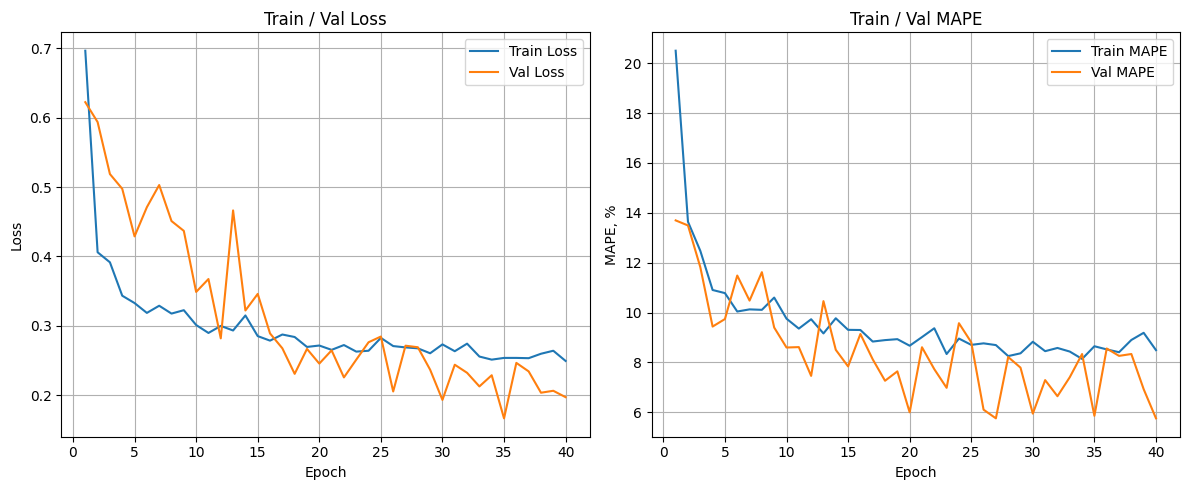

In [150]:
epochs_range = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_mape"], label="Train MAPE")
plt.plot(epochs_range, history["val_mape"], label="Val MAPE")
plt.xlabel("Epoch")
plt.ylabel("MAPE, %")
plt.title("Train / Val MAPE")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Предсказания.

#### Функции для получения предсказаний.

MAPE

In [151]:
def calculate_mape_torch(y_true, y_pred, eps=1e-8):
    denom = torch.clamp(torch.abs(y_true), min=eps)
    mape_per_dim = torch.mean(torch.abs((y_true - y_pred) / denom), dim=0) * 100.0
    mape_mean = torch.mean(mape_per_dim)
    return mape_mean.item(), mape_per_dim.detach().cpu().numpy()

Обработчик батчей

In [152]:
def unpack_batch(batch, device):
    if len(batch) == 3:
        x_batch, y_batch, mask_batch = batch
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)
        return x_batch, y_batch, mask_batch
    else:
        x_batch, y_batch = batch
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        return x_batch, y_batch, None

Тестирование модели.

In [153]:
def test_model(model, test_loader, device):
    model.eval()

    all_y_true = []
    all_y_pred = []

    test_loss = 0.0

    with torch.no_grad():
        test_pbar = tqdm(test_loader, desc="Testing")

        for batch in test_pbar:
            if len(batch) == 3:
                x_batch, y_batch, mask_batch = batch
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                mask_batch = mask_batch.to(device)

                output = model(x_batch, mask_batch)
            else:
                x_batch, y_batch = batch
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                output = model(x_batch)

            loss = criterion(output, y_batch)
            test_loss += loss.item()

            all_y_true.append(y_batch.cpu())
            all_y_pred.append(output.cpu())

            test_pbar.set_postfix({"test_loss": f"{loss.item():.4f}"})

    test_loss /= len(test_loader)

    y_true = torch.cat(all_y_true, dim=0) * y_std + y_mean
    y_pred = torch.cat(all_y_pred, dim=0) * y_std + y_mean

    mape = calculate_mape(y_true, y_pred)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"MAPE: {100*mape}%")

    return y_true, y_pred, mape

Получение предсказания.

In [154]:
def predict(model, data_loader, device):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting"):
            if len(batch) == 3:
                x_batch, y_batch, mask_batch = batch
                x_batch = x_batch.to(device)
                mask_batch = mask_batch.to(device)

                output = model(x_batch, mask_batch)
            else:
                x_batch, y_batch = batch
                x_batch = x_batch.to(device)

                output = model(x_batch)

            all_predictions.append(output.cpu())
            all_targets.append(y_batch.cpu())

    predictions = torch.cat(all_predictions, dim=0).numpy()
    targets = torch.cat(all_targets, dim=0).numpy()

    return predictions, targets

In [155]:
@torch.no_grad()
def test_model(model, test_loader, criterion, device, y_mean, y_std, target_cols=None):
    test_loss, test_mape, test_mape_per_dim, y_true, y_pred = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device,
        y_mean=y_mean,
        y_std=y_std,
        desc="Testing"
    )

    print(f"Test Loss: {test_loss:.5f}")
    print(f"Test MAPE: {test_mape:.3f}%")

    if target_cols is not None:
        print("\nMAPE by parameter:")
        for name, value in zip(target_cols, test_mape_per_dim):
            print(f"{name}: {value:.3f}%")

    return {
        "test_loss": test_loss,
        "test_mape": test_mape,
        "test_mape_per_dim": test_mape_per_dim,
        "y_true": y_true,
        "y_pred": y_pred
    }

#### Итоговые предсказания.

In [156]:
target_cols = ['R0', 'R1', 'R2', 'C1', 'C2']

results = test_model(
    model=model,
    test_loader=val_loader,
    criterion=criterion,
    device=device,
    y_mean=y_mean,
    y_std=y_std,
    target_cols=target_cols
)

y_true = results["y_true"]
y_pred = results["y_pred"]
mape = results["test_mape"]

Test Loss: 0.16639
Test MAPE: 5.858%

MAPE by parameter:
R0: 1.681%
R1: 6.271%
R2: 8.004%
C1: 5.597%
C2: 7.736%


In [157]:
y_true[:3]

tensor([[3.8244e-02, 2.0053e-02, 3.7910e-03, 2.5418e+03, 2.6378e+04],
        [3.9573e-02, 2.9765e-02, 6.8808e-03, 3.3073e+03, 1.4533e+04],
        [4.0419e-02, 2.6845e-02, 9.5486e-03, 4.0397e+03, 1.0473e+04]])

In [158]:
y_pred[:3]

tensor([[3.7593e-02, 1.8768e-02, 3.5769e-03, 2.7348e+03, 2.9361e+04],
        [3.8872e-02, 2.4626e-02, 7.1218e-03, 3.3904e+03, 1.4350e+04],
        [4.0115e-02, 2.4048e-02, 9.8142e-03, 4.2660e+03, 1.0025e+04]])

In [162]:
summary_rows = []
for col in target_cols:
    true_col = df_compare[f'true_{col}'].to_numpy()
    pred_col = df_compare[f'pred_{col}'].to_numpy()
    abs_err = np.abs(pred_col - true_col)
    sq_err = (pred_col - true_col) ** 2
    ape = abs_err / np.clip(np.abs(true_col), 1e-8, None) * 100.0

    summary_rows.append({
        'parameter': col,
        'true_mean': np.mean(true_col),
        'pred_mean': np.mean(pred_col),
        'true_std': np.std(true_col),
        'pred_std': np.std(pred_col),
        'MSE': np.mean(sq_err),
        'MAE': np.mean(abs_err),
        'MAPE': np.mean(ape),
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,parameter,true_mean,pred_mean,true_std,pred_std,MSE,MAE,MAPE
0,R0,0.037759,0.037682,0.001215,0.001209,5.855804e-07,0.000640,1.681357
1,R1,0.016681,0.016556,0.005064,0.004159,4.280030e-06,0.001261,6.270554
2,R2,0.004292,0.004268,0.002620,0.002951,2.930341e-07,0.000365,8.004309
3,C1,2910.770752,2875.053467,650.354736,777.812927,4.290012e+04,170.688477,5.597322
4,C2,31651.693359,31973.435547,15182.369141,14270.942383,7.401040e+06,2132.100098,7.735812
